In [2]:

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Accidents Dataset") \
    .getOrCreate()

df = spark.read.option("header", True).csv(
    "hdfs://namenode:9000/user/gyembo/project/traffic_cleaned_eda_csv"
)
df.show(5)
df.printSchema()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/24 09:11:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/24 09:11:30 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------+--------------------+--------------------+------------------+----------+------------+----------+---------+-----+-------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-------+--------+--------+-------+-------+-----+--------------+--------------+----+-----+---------+----+------------------+
|Severity|          Start_Time|            End_Time|         Start_Lat| Start_Lng|Distance(mi)|      City|   County|State|Country|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Weather_Condition|Amenity|Crossing|Junction|Railway|Station| Stop|Traffic_Signal|Sunrise_Sunset|Hour|Month|DayOfWeek|Year|  Duration_Minutes|
+--------+--------------------+--------------------+------------------+----------+------------+----------+---------+-----+-------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-------+--------+--------+-------+-------+-----+--

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np


# color pallete

PALETTE = {
    "bg":        "#0d1117",
    "panel":     "#161b22",
    "accent1":   "#58a6ff",
    "accent2":   "#3fb950",
    "accent3":   "#f78166",
    "accent4":   "#d29922",
    "accent5":   "#bc8cff",
    "text":      "#e6edf3",
    "grid":      "#21262d",
}

# Severity Color

SEV_COLORS = {
    1: PALETTE["accent2"],
    2: PALETTE["accent1"],
    3: PALETTE["accent4"],
    4: PALETTE["accent3"]
}

# Category Palette

CAT_CMAP = [
    PALETTE["accent1"], PALETTE["accent5"], PALETTE["accent2"],
    PALETTE["accent4"], PALETTE["accent3"],
    "#79c0ff", "#56d364", "#ffa657", "#ff7b72", "#cae8ff"
]

# GLOBAL STYLE CONFIG

plt.rcParams.update({
    "figure.facecolor":  PALETTE["bg"],
    "axes.facecolor":    PALETTE["panel"],
    "axes.edgecolor":    PALETTE["grid"],
    "axes.labelcolor":   PALETTE["text"],
    "xtick.color":       PALETTE["text"],
    "ytick.color":       PALETTE["text"],
    "text.color":        PALETTE["text"],
    "grid.color":        PALETTE["grid"],
    "grid.linestyle":    "--",
    "grid.alpha":        0.6,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlepad":     12,
})

# SAFE STYLE FUNCTION

def style_ax(ax, title="", xlabel="", ylabel=""):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.grid(True, axis="y", alpha=0.4)

    # SAFE spine removal (avoids version errors)
    for spine in ax.spines.values():
        spine.set_visible(False)

    return ax

In [4]:
# GEO DATA EXTRACTIOn

from pyspark.sql.functions import col

geo_cols = ["Start_Lat", "Start_Lng", "Severity", "State",
            "City", "Weather_Condition", "Start_Time"]

# Select only needed columns early
geo_df = df.select(geo_cols)



# Small controlled sampling 
geo_df = geo_df.sample(withReplacement=False, fraction=0.02, seed=42)

# Hard cap rows (prevents VM crash)
geo_df = geo_df.limit(200000)

# repartition for efficient execution
geo_df = geo_df.repartition(4)

# Convert ONLY final small dataset to Pandas
geo_pd = geo_df.toPandas()

# Type casting in pandas (safe now)
geo_pd["Start_Lat"] = geo_pd["Start_Lat"].astype(float)
geo_pd["Start_Lng"] = geo_pd["Start_Lng"].astype(float)
geo_pd["Severity"]  = geo_pd["Severity"].astype(int)

print(f"Working with {len(geo_pd):,} records for geospatial analysis")

Working with 154,509 records for geospatial analysis


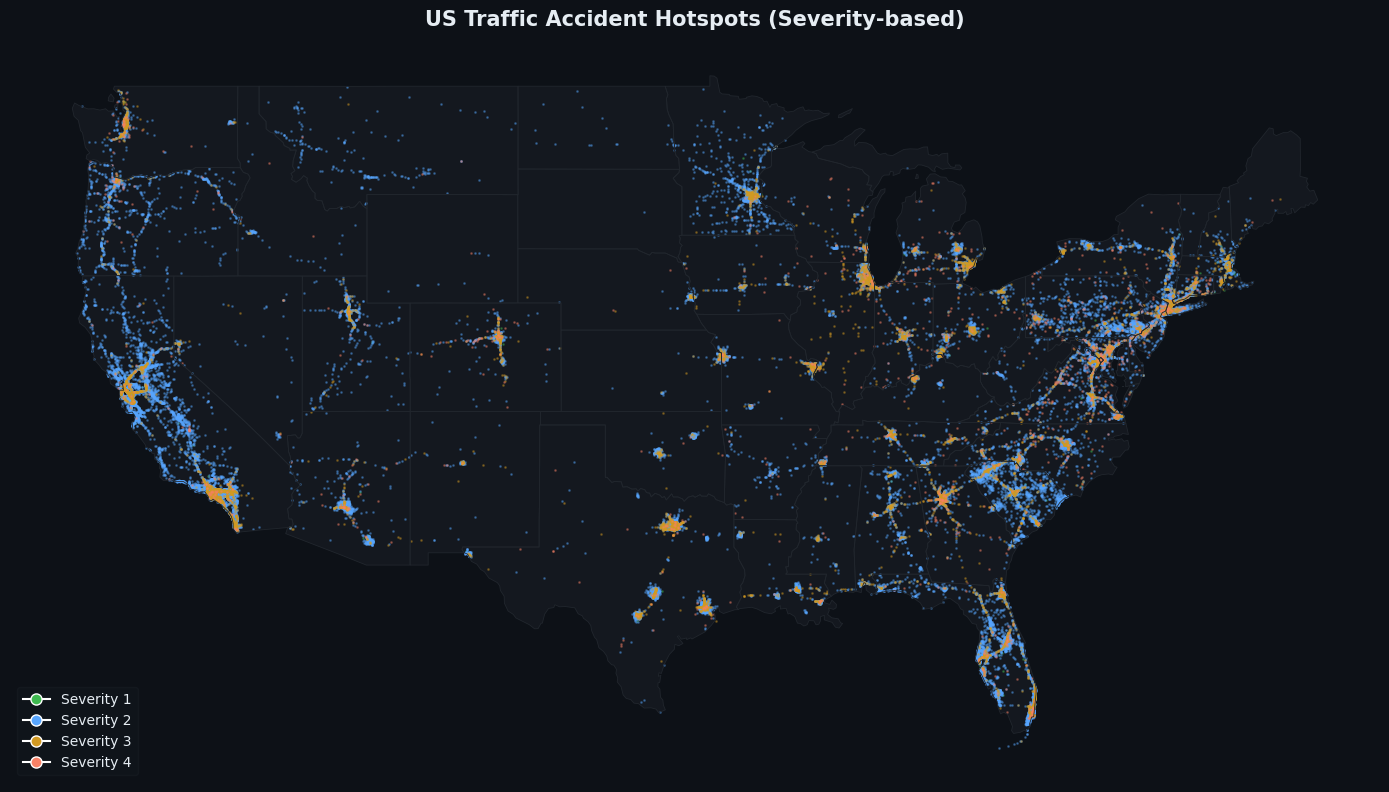

In [5]:
# 1. Accident Hotspot Map 

from shapely.geometry import Point
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

MAX_POINTS = 50000

gdf_small = geo_pd.sample(
    n=min(len(geo_pd), MAX_POINTS),
    random_state=42
).copy()

# Build GeoDataFrame
geometry = gpd.points_from_xy(
    gdf_small["Start_Lng"],
    gdf_small["Start_Lat"]
)

gdf = gpd.GeoDataFrame(gdf_small, geometry=geometry, crs="EPSG:4326")

# US MAP
us_states = gpd.read_file(
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
)

us_states = us_states.to_crs("EPSG:4326")

us_cont = us_states[~us_states["name"].isin(["Alaska", "Hawaii", "Puerto Rico"])]

# FILTER CONTINENTAL US
gdf_cont = gdf[
    (gdf["Start_Lng"].between(-125, -66)) &
    (gdf["Start_Lat"].between(24, 50))
]

# STEP 5 — PLOT 
fig, ax = plt.subplots(figsize=(14, 8), facecolor=PALETTE["bg"])
ax.set_facecolor(PALETTE["panel"])

# base map (themed)
us_cont.boundary.plot(
    ax=ax,
    linewidth=0.6,
    color=PALETTE["grid"]
)

us_cont.plot(
    ax=ax,
    color=PALETTE["panel"],
    alpha=0.8
)

# ACCIDENT POINTS (USING YOUR SEVERITY COLORS)
for sev in [1, 2, 3, 4]:
    subset = gdf_cont[gdf_cont["Severity"] == sev]

    ax.scatter(
        subset["Start_Lng"],
        subset["Start_Lat"],
        s=1,
        alpha=0.35,
        c=SEV_COLORS[sev],   # ✅ your palette system
        label=f"Severity {sev}"
    )

# LEGEND (THEMED)
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=SEV_COLORS[s],
        markersize=8,
        label=f"Severity {s}"
    )
    for s in [1, 2, 3, 4]
]

legend = ax.legend(
    handles=legend_elements,
    loc="lower left",
    framealpha=0.3,
    facecolor=PALETTE["panel"],
    edgecolor=PALETTE["grid"],
    fontsize=10
)

# legend text color fix
for text in legend.get_texts():
    text.set_color(PALETTE["text"])

# TITLE + STYLE
ax.set_title(
    "US Traffic Accident Hotspots (Severity-based)",
    color=PALETTE["text"],
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_axis_off()

plt.tight_layout()

plt.savefig(
    "geo_hotspot_map.png",
    dpi=120,
    facecolor=PALETTE["bg"],
    bbox_inches="tight"
)

plt.show()

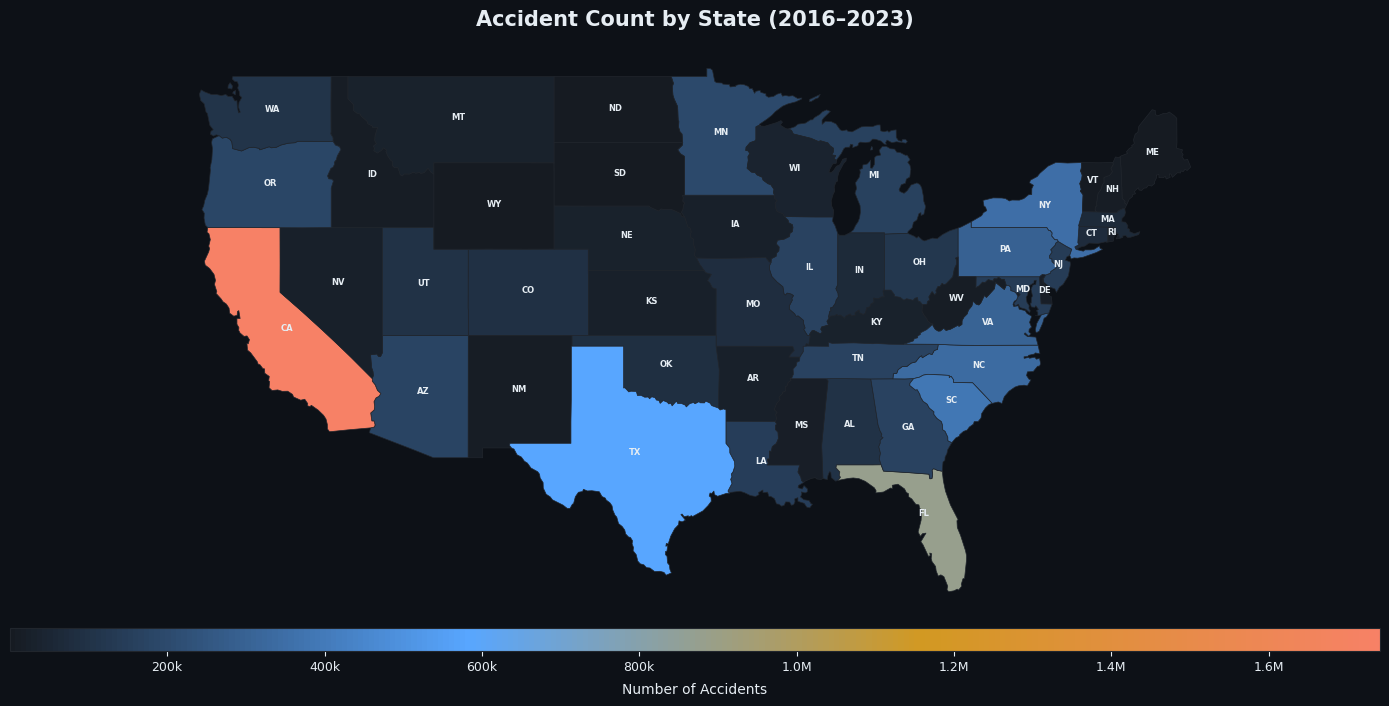

In [9]:
# 2. STATE CHOROPLETH

import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Spark aggregation 
state_counts = (
    df.groupBy("State")
      .count()
      .toPandas()
      .rename(columns={"State": "state_code", "count": "accidents"})
)

state_counts["state_code"] = state_counts["state_code"].str.upper().str.strip()

# State mapping
state_counts["name"] = state_counts["state_code"].map(STATE_MAP)
state_counts.dropna(subset=["name"], inplace=True)

# Load map
us_states = gpd.read_file(
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
)

us_states = us_states.to_crs("EPSG:4326")
us_cont = us_states[~us_states["name"].isin(["Alaska", "Hawaii", "Puerto Rico"])].copy()

# Normalize merge keys
us_cont["name_key"] = us_cont["name"].str.lower().str.strip()
state_counts["name_key"] = state_counts["name"].str.lower().str.strip()

merged = us_cont.merge(state_counts, on="name_key", how="left")
merged["accidents"] = merged["accidents"].fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(PALETTE["bg"])
ax.set_facecolor(PALETTE["bg"])

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="4%", pad=0.1)
cax.set_facecolor(PALETTE["bg"])

from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "custom",
    [PALETTE["panel"], PALETTE["accent1"], PALETTE["accent4"], PALETTE["accent3"]]
)

merged.plot(
    column="accidents",
    cmap=custom_cmap,
    linewidth=0.5,
    edgecolor=PALETTE["grid"],
    legend=True,
    cax=cax,
    legend_kwds={"orientation": "horizontal"},
    missing_kwds={"color": PALETTE["panel"]},
    ax=ax
)

# Colorbar styling
cax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}k"
))

cax.tick_params(colors=PALETTE["text"], labelsize=9)
cax.set_xlabel(
    "Number of Accidents",
    color=PALETTE["text"],
    fontsize=10,
    labelpad=6
)

# State labels
for _, row in merged.iterrows():
    if pd.notna(row.get("state_code")) and row["state_code"] != "DC":
        centroid = row.geometry.centroid
        ax.text(
            centroid.x,
            centroid.y,
            row["state_code"],
            fontsize=6,
            ha="center",
            color=PALETTE["text"],
            fontweight="bold"
        )

# Title + styling
ax.set_title(
    "Accident Count by State (2016–2023)",
    fontsize=15,
    fontweight="bold",
    pad=12,
    color=PALETTE["text"]
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    "geo_state_choropleth.png",
    dpi=120,
    bbox_inches="tight",
    facecolor=PALETTE["bg"]
)

plt.show()

Top 10 cities:
       City State  accidents
      Miami    FL     186768
    Houston    TX     169428
Los Angeles    CA     156491
  Charlotte    NC     138345
     Dallas    TX     130303
    Orlando    FL     109690
     Austin    TX      96604
    Raleigh    NC      86066
  Nashville    TN      72670
Baton Rouge    LA      71588


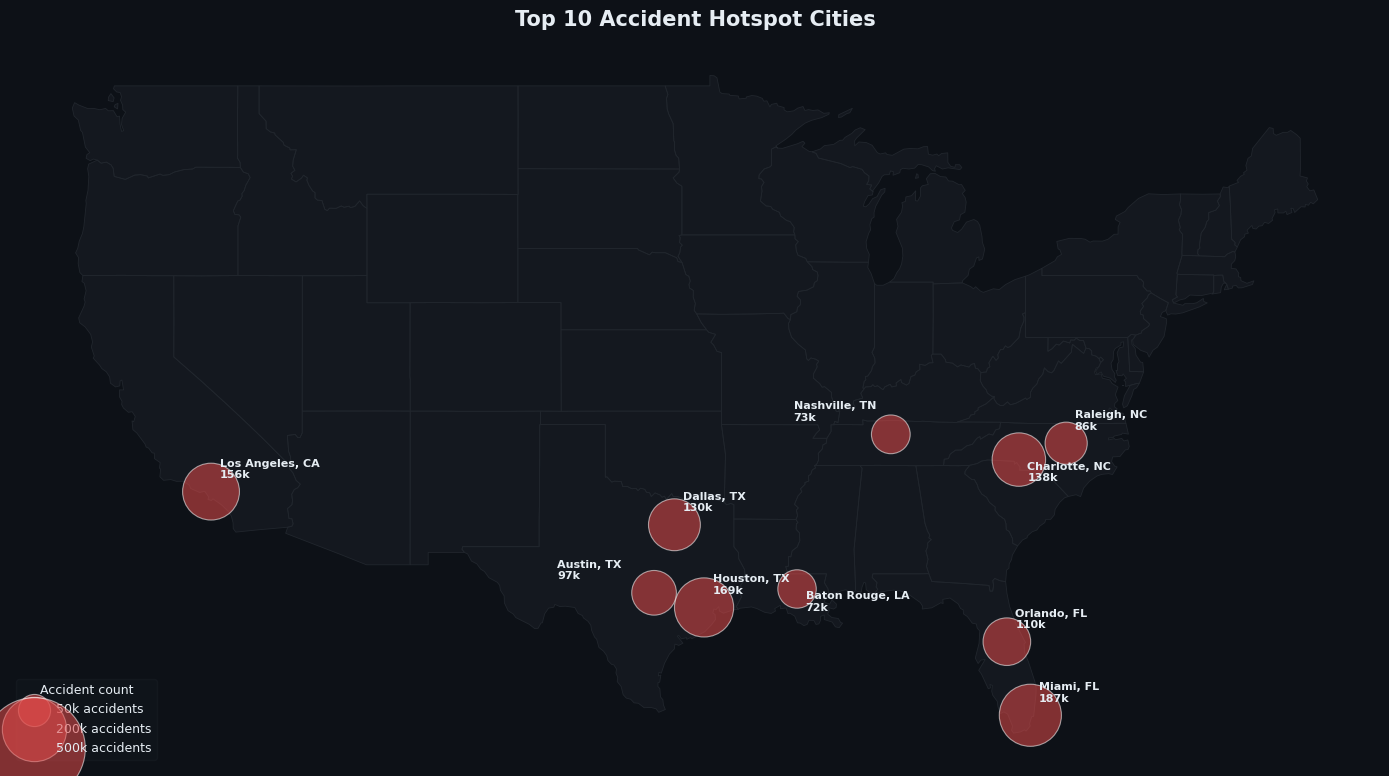

In [12]:
# 3. TOP 10 CITY BUBBLE MAP 
from pyspark.sql import functions as F

DANGER     = "#E24B4A"
SEV_COLORS = {1: "#9FE1CB", 2: "#1D9E75", 3: "#EF9F27", 4: "#E24B4A"}

# Pull top 10 cities from full df 
city_pd = (
    df.groupBy("City", "State")
      .agg(
          F.count("*").alias("accidents"),
          F.avg("Start_Lat").alias("lat"),
          F.avg("Start_Lng").alias("lng")
      )
      .orderBy(F.desc("accidents"))
      .limit(10)
      .toPandas()
)

# Fix casing 
city_pd["State"] = city_pd["State"].str.upper().str.strip()
city_pd["City"]  = city_pd["City"].str.title()

# Filter continental US only 
city_pd = city_pd[
    city_pd["lng"].between(-125, -66) &
    city_pd["lat"].between(24, 50)
].copy()

print("Top 10 cities:")
print(city_pd[["City", "State", "accidents"]].to_string(index=False))

# Manual label offsets to avoid overlap 
offsets = {
    "Houston":     ( 0.4,  0.5),
    "Miami":       ( 0.4,  0.5),
    "Charlotte":   ( 0.4, -0.8),
    "Raleigh":     ( 0.4,  0.5),
    "Austin":      (-4.5,  0.5),
    "Dallas":      ( 0.4,  0.5),
    "Nashville":   (-4.5,  0.5),
    "Orlando":     ( 0.4,  0.5),
    "Baton Rouge": ( 0.4, -0.8),
    "Los Angeles": ( 0.4,  0.5),
}

# Plot 
fig, ax = plt.subplots(figsize=(14, 8), facecolor=PALETTE["bg"])
ax.set_facecolor(PALETTE["bg"])

us_cont.boundary.plot(ax=ax, linewidth=0.6, color=PALETTE["grid"])
us_cont.plot(ax=ax, color=PALETTE["panel"], alpha=0.8)

# Bubbles 
max_acc           = city_pd["accidents"].max()
city_pd["bubble"] = (city_pd["accidents"] / max_acc) * 2000

ax.scatter(
    city_pd["lng"], city_pd["lat"],
    s=city_pd["bubble"],
    c=DANGER, alpha=0.55,
    edgecolors="white", linewidths=0.8,
    zorder=5
)

# Labels with offsets 
for _, row in city_pd.iterrows():
    ox, oy = offsets.get(row["City"], (0.4, 0.4))
    ax.text(
        row["lng"] + ox, row["lat"] + oy,
        f"{row['City']}, {row['State']}\n{row['accidents']/1e3:.0f}k",
        fontsize=8, color=PALETTE["text"],
        fontweight="bold", zorder=6
    )

# Bubble size legend 
for size_val in [50000, 200000, 500000]:
    ax.scatter([], [],
               s=(size_val / max_acc) * 2000,
               c=DANGER, alpha=0.55,
               edgecolors="white", linewidths=0.8,
               label=f"{size_val/1e3:.0f}k accidents")

legend = ax.legend(
    title="Accident count", loc="lower left",
    framealpha=0.3, facecolor=PALETTE["panel"],
    edgecolor=PALETTE["grid"], fontsize=9, title_fontsize=9
)
for text in legend.get_texts():
    text.set_color(PALETTE["text"])
legend.get_title().set_color(PALETTE["text"])

ax.set_title("Top 10 Accident Hotspot Cities",
             fontsize=15, fontweight="bold",
             pad=12, color=PALETTE["text"])
ax.axis("off")

plt.tight_layout()
plt.savefig("geo_city_bubbles.png", dpi=120,
            bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()

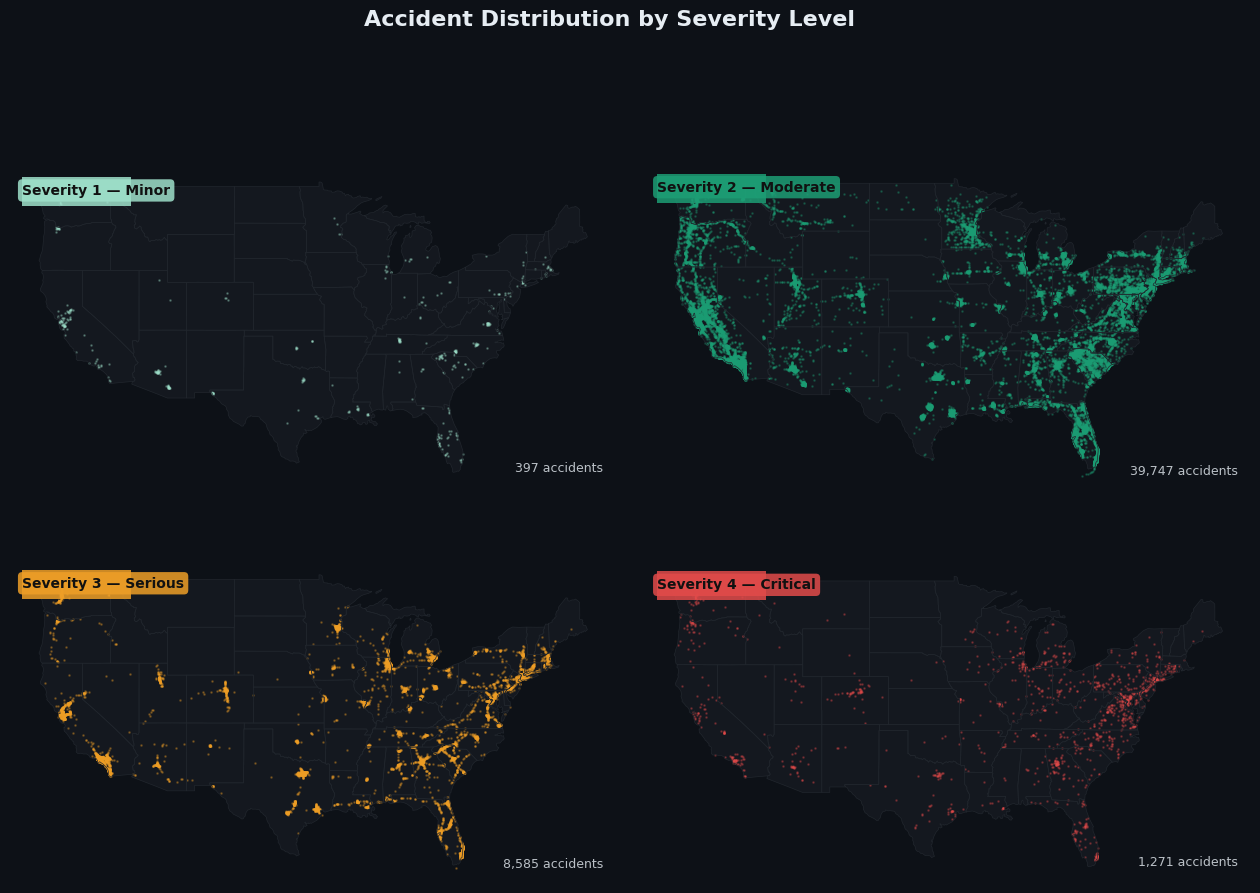

In [8]:
# 4. SEVERITY FACET MAPS (2×2 GRID)
from pyspark.sql import functions as F

SEV_COLORS = {1: "#9FE1CB", 2: "#1D9E75", 3: "#EF9F27", 4: "#E24B4A"}
SEV_LABELS = {
    1: "Minor",
    2: "Moderate",
    3: "Serious",
    4: "Critical"
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor=PALETTE["bg"])
fig.subplots_adjust(hspace=0.05, wspace=0.05)
axes = axes.flatten()

for i, sev in enumerate([1, 2, 3, 4]):
    ax = axes[i]
    ax.set_facecolor(PALETTE["panel"])

    # ── Base map ──
    us_cont.boundary.plot(ax=ax, linewidth=0.5, color=PALETTE["grid"])
    us_cont.plot(ax=ax, color=PALETTE["panel"], alpha=0.8)

    # ── Filter severity ──
    subset = gdf_cont[gdf_cont["Severity"] == sev]

    # ── Scatter points ──
    ax.scatter(
        subset["Start_Lng"],
        subset["Start_Lat"],
        s=0.8,
        alpha=0.3,
        c=SEV_COLORS[sev],
        rasterized=True        # faster rendering for large point clouds
    )

    # Severity color badge 
    ax.add_patch(plt.Rectangle(
        (0.02, 0.88), 0.18, 0.09,
        transform=ax.transAxes,
        facecolor=SEV_COLORS[sev],
        alpha=0.85,
        zorder=5,
        clip_on=False
    ))
    ax.text(
        0.02, 0.95,
        f"Severity {sev} — {SEV_LABELS[sev]}",
        transform=ax.transAxes,
        fontsize=10, fontweight="bold",
        ha="left", va="top",                  # ← left aligned, no rectangle needed
        color="#111",
        bbox=dict(
            facecolor=SEV_COLORS[sev],        # ← bbox auto-fits the text width
            edgecolor="none",
            boxstyle="round,pad=0.3",
            alpha=0.85
        ),
        zorder=6
    )

    # Accident count 
    ax.text(
        0.98, 0.04,
        f"{len(subset):,} accidents",
        transform=ax.transAxes,
        fontsize=9, ha="right", va="bottom",
        color=PALETTE["text"], alpha=0.8
    )

    ax.axis("off")

fig.suptitle(
    "Accident Distribution by Severity Level",
    fontsize=16, fontweight="bold",
    color=PALETTE["text"], y=1.01
)

plt.savefig(
    "geo_severity_facets.png",
    dpi=120, bbox_inches="tight",
    facecolor=PALETTE["bg"]
)
plt.show()